In [19]:
from langgraph.graph import StateGraph, START,END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_openrouter import ChatOpenRouter

In [35]:
load_dotenv()
model = ChatOpenRouter(
    model='nvidia/nemotron-3-nano-30b-a3b:free'
)

In [36]:
# delfine the state

class BlogState(TypedDict):
    title: str
    outline : str
    content : str

In [37]:
def blog_outline(state: BlogState) -> BlogState:
    # extract blog topic
    title = state['title']

    # invoke llm to create the outline with prompt
    prompt = f'Generate a detailed outline for a blog on the topic {title}'
    
    outline = model.invoke(prompt).content

    # add the outline to the state
    state['outline'] = outline

    # return state
    return state


def final_blog(state: BlogState) -> BlogState:
    # extract the outline from state
    title = state['title']
    outline = state['outline']

    # invoke llm to crate teh final blog
    prompt = f'Write a detailed blog on the title - {title} using the following outline : {outline}'

    final_blog_post = model.invoke(prompt).content

    # add the content to the blogstate
    state['content'] =  final_blog_post

    # return the state
    return state

In [38]:
## define the graph

blog_graph = StateGraph(BlogState)

# add nodes
blog_graph.add_node('blog_outline', blog_outline)
blog_graph.add_node('final_blog', final_blog)

# add edges
blog_graph.add_edge(START, 'blog_outline')
blog_graph.add_edge('blog_outline', 'final_blog')
blog_graph.add_edge('final_blog', END)

# compile graph and store
blog_workflow = blog_graph.compile()


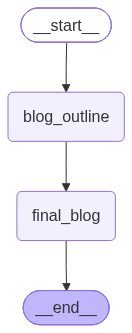

In [44]:
blog_graph.compile()

In [39]:
## execute the graph 

inital_state = {'title':'5 ways to earn passive income from india'}

final_state = blog_workflow.invoke(inital_state)

print(final_state) 

{'title': '5 ways to earn passive income from india', 'outline': '**Blog Post Outline**  \n**Title:** *5 Proven Ways to Earn Passive Income in India (2025 Update)*  \n\n---\n\n### 1. Introduction  \n   - **Hook:** A quick anecdote or statistic (e.g., “Over 60% of Indian households are looking for extra streams of income without a 9‑to‑5 grind”).  \n   - **What is Passive Income?** – definition, why it’s attractive, and the myths vs. realities.  \n   - **Why India?** – brief snapshot of the growing digital infrastructure, young population, and fintech boom.  \n   - **What Readers Will Learn:** preview the 5 actionable methods and the realistic time‑to‑earn expectations.\n\n---\n\n### 2. Method #1 – **Investing in Dividend‑Paying Stocks & Mutual Funds**  \n   - **A. Why It Works in India** – talk about SEBI‑regulated markets, SIP (Systematic Investment Plan) culture, and the rise of retail participation.  \n   - **B. How to Get Started**  \n        1. Open a demat & trading account (e.g.

In [40]:
print(final_state['outline'])

**Blog Post Outline**  
**Title:** *5 Proven Ways to Earn Passive Income in India (2025 Update)*  

---

### 1. Introduction  
   - **Hook:** A quick anecdote or statistic (e.g., “Over 60% of Indian households are looking for extra streams of income without a 9‑to‑5 grind”).  
   - **What is Passive Income?** – definition, why it’s attractive, and the myths vs. realities.  
   - **Why India?** – brief snapshot of the growing digital infrastructure, young population, and fintech boom.  
   - **What Readers Will Learn:** preview the 5 actionable methods and the realistic time‑to‑earn expectations.

---

### 2. Method #1 – **Investing in Dividend‑Paying Stocks & Mutual Funds**  
   - **A. Why It Works in India** – talk about SEBI‑regulated markets, SIP (Systematic Investment Plan) culture, and the rise of retail participation.  
   - **B. How to Get Started**  
        1. Open a demat & trading account (e.g., Zerodha, Upstox, Groww).  
        2. Choose high‑yield stocks or dividend‑focus

In [41]:
print(final_state['content'])

## 5 Proven Ways to Earn Passive Income in India (2025 Update)

*If you’re reading this, chances are you’ve already dreamed about a life where money keeps flowing while you sleep. In India, that dream is no longer a distant fantasy—​it’s becoming a daily reality for millions of savvy investors.*  

Below you’ll find **five battle‑tested, legally‑sound passive‑income streams** that anyone with a modest amount of capital (or time) can start today. Each method is broken down into step‑by‑step instructions, realistic return expectations, pitfalls to avoid, and a **30‑day kick‑start checklist** you can copy‑paste into your phone or planner.  

> **TL;DR:** Pick the strategy (or a blend) that matches your capital, risk appetite, and skill set, automate it, and watch the cash trickle in month after month.

---

### 1️⃣ Introduction  

#### Hook  
> *“Over 60% of Indian households are looking for extra streams of income without a 9‑to‑5 grind.”* – a recent **Nifty‑500 Financial Literacy Survey

In [42]:
print(final_state)

{'title': '5 ways to earn passive income from india', 'outline': '**Blog Post Outline**  \n**Title:** *5 Proven Ways to Earn Passive Income in India (2025 Update)*  \n\n---\n\n### 1. Introduction  \n   - **Hook:** A quick anecdote or statistic (e.g., “Over 60% of Indian households are looking for extra streams of income without a 9‑to‑5 grind”).  \n   - **What is Passive Income?** – definition, why it’s attractive, and the myths vs. realities.  \n   - **Why India?** – brief snapshot of the growing digital infrastructure, young population, and fintech boom.  \n   - **What Readers Will Learn:** preview the 5 actionable methods and the realistic time‑to‑earn expectations.\n\n---\n\n### 2. Method #1 – **Investing in Dividend‑Paying Stocks & Mutual Funds**  \n   - **A. Why It Works in India** – talk about SEBI‑regulated markets, SIP (Systematic Investment Plan) culture, and the rise of retail participation.  \n   - **B. How to Get Started**  \n        1. Open a demat & trading account (e.g.

In [43]:
import inspect
from langchain_openrouter import ChatOpenRouter
from langchain_core.outputs import ChatResult

print('ChatOpenRouter.invoke attr exists:', hasattr(ChatOpenRouter, 'invoke'))
print('ChatOpenRouter.invoke signature:', inspect.signature(ChatOpenRouter.invoke))
print('ChatOpenRouter methods containing invoke/generate:', [m for m in dir(ChatOpenRouter) if 'invoke' in m or 'generate' in m])
print('ChatResult attrs:', [a for a in dir(ChatResult) if not a.startswith('_')][:50])
print('ChatResult annotations:', getattr(ChatResult, '__annotations__', None))
print('ChatResult mro:', ChatResult.__mro__)


ChatOpenRouter.invoke attr exists: True
ChatOpenRouter.invoke signature: (self, input: 'LanguageModelInput', config: 'RunnableConfig | None' = None, *, stop: 'list[str] | None' = None, **kwargs: 'Any') -> 'AIMessage'
ChatOpenRouter methods containing invoke/generate: ['_agenerate', '_agenerate_with_cache', '_generate', '_generate_with_cache', 'agenerate', 'agenerate_prompt', 'ainvoke', 'generate', 'generate_prompt', 'invoke']
ChatResult attrs: ['construct', 'copy', 'dict', 'from_orm', 'json', 'model_computed_fields', 'model_config', 'model_construct', 'model_copy', 'model_dump', 'model_dump_json', 'model_extra', 'model_fields', 'model_fields_set', 'model_json_schema', 'model_parametrized_name', 'model_post_init', 'model_rebuild', 'model_validate', 'model_validate_json', 'model_validate_strings', 'parse_file', 'parse_obj', 'parse_raw', 'schema', 'schema_json', 'update_forward_refs', 'validate']
ChatResult annotations: {'generations': list[langchain_core.outputs.chat_generation.ChatGener